# YOUR PROJECT TITLE

> **Note the following:** 
> 1. This is *not* meant to be an example of an actual **model analysis project**, just an example of how to structure such a project.
> 1. Remember the general advice on structuring and commenting your code
> 1. The `modelproject.py` file includes a function which could be used multiple times in this notebook.

Imports and set magics:

In [14]:
import numpy as np
from scipy import optimize
import sympy as sm

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# local modules
import modelproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Model description

Our project analyses the Overlapping generations (OLG) model. The OLG model is a cornerstone model of modern economics. It investigates intergeneraltional allocation and the life-cycle behavior (investment in human capital, work and saving for retirement). 

In the OLG model, we have 2 periods, one when individuals are young, period 1 and one when they are old, period t+1. 
Induviduals are born in period t.

$$L_t =L_{t+1}(1+n)$$

There are $L_t$ young people and $L_{t+1}$ old people. n is the population growth

**Firms**: We have in the OLG model that firms are competitive, identical and maximize their profits as such:

$$
\begin{aligned}
\pi_t & =\max_{K_{t},L_t} AK_t^\alpha L_t^{1-\alpha}-r_tK_t-w_tL_t\\
\end{aligned}
$$
This is a Cobb-Douglas production-function. $K_{t}$ is the capital, $L_t$ is the labor and $A$ is the technology level, $\alpha$ is a parameter, $\in (0, 1)$.

We define kapital in per capita terms, and we have that the rent on capital is its marginal product. And the cost of labour is the wage which is also its marginal product.
$$
\begin{aligned}
k_t & =\frac{K_t}{L_t} \\
r_t & = \alpha A k_t^{\alpha-1} \\
w_t & = (1-\alpha) A k_t^{\alpha}
\end{aligned}
$$


The budget constraint for the young and old is: 

$$
c_{1t} + s_t = w_t 
$$

$$
c_{2t+1} = (1 + r_{t+1}) s_t
$$

The young consume their wage and saves for when they are old. The old then get these savings and the interest rate they got on the savings. 

The lifetime budget constraint then becomes:

$$c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = w_t $$

The old consumes all of their remaining saved wages. We see that all consumtion comes from the wage made in period 1. 

Utility for the households is:
    
$$
\begin{aligned}
U_t & = u(c_{1t})+\frac{1}{1+\rho} u(c_{2t+1})\\
\end{aligned}
$$

$\rho$ is the discount rate, i.e. the measure of patience of the households, i.e. how much consumption the househoplds wants when young in period 1 and when old in period 2. A higher $\rho$ means more impatient households, $\rho \in (0,1)$.

We can now solve the households maximization problem:

$$ \max_{c_{1t}, c_{2t+1}} \left( u(c_{1t}) + \frac{1}{1+\rho} u(c_{2t+1}) \right) $$

Subject to the budget constraint:

$$ c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = W_t $$

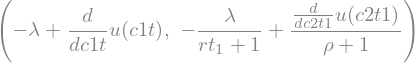

In [17]:
from sympy import symbols, Function, diff, Eq, solve

# Define the symbols
c1t, c2t1, Wt, rt1, rho, lam = symbols('c1t c2t1 Wt rt1 rho lambda')

# Define the utility functions
u = Function('u')

# Define the Lagrangian
L = u(c1t) + 1 / (1 + rho) * u(c2t1) + lam * (Wt - c1t - c2t1 / (1 + rt1))

# Compute the first order conditions
foc_c1t = diff(L, c1t)
foc_c2t1 = diff(L, c2t1)

# Solve the first order conditions
foc_eqs = [Eq(foc_c1t, 0), Eq(foc_c2t1, 0)]

# Display the FOCs and the solution for lambda
foc_c1t, foc_c2t1

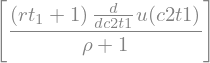

In [16]:
# Extract expressions for lambda from each FOC
lambda_c1t = solve(Eq(foc_c1t, 0), lam)[0]
lambda_c2t1 = solve(Eq(foc_c2t1, 0), lam)[0]

# Equate and solve for the Euler equation
euler_eq = Eq(lambda_c1t, lambda_c2t1)
euler_solution = solve(euler_eq, diff(u(c1t), c1t))

euler_solution

## Numerical solution

You can always solve a model numerically. 

Define first the set of parameters you need. 

Then choose one of the optimization algorithms that we have gone through in the lectures based on what you think is most fitting for your model.

Are there any problems with convergence? Does the model converge for all starting values? Make a lot of testing to figure these things out. 

# Further analysis

Make detailed vizualizations of how your model changes with parameter values. 

Try to make an extension of the model. 

# Conclusion

Add concise conclusion. 